# Sentiment Analysis - Trained on the Real IMDB Dataset (15,000 Reviews)


## 1. Import Libraries

In [1]:
import re
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

pd.set_option('display.max_colwidth', 100)

## 2. Load the Dataset

This loads the real, cleaned 15,000-record IMDB dataset created from the Stanford AI Large Movie Review Dataset.

In [2]:
df = pd.read_csv("imdb_sentiment_dataset_15000.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (15000, 3)


,review_id,review,sentiment
0,1,"Visconti's first feature, Ossessione is an adaptation of James M. Cain's The Postman Always Ring...",positive
1,2,"I always follow the Dakar, so when my husband bought Charlie's 'Race to Dakar' DVD home I couldn...",positive
2,3,I used to watch this on either HBO or Showtime or Cinemax during the one summer in the mid 90's ...,positive
3,4,Sigh I sincerely wonder why all the acclaimed and supposedly profound movie critics hold such a...,positive
4,5,One more of extremely unprofessional movies about computer programmers.<br /><br />Looks authors...,negative


## 3. Explore Class Balance

In [3]:
print(df['sentiment'].value_counts())
print()
print("Unique reviews:", df['review'].nunique())
print("Average review length (chars):", round(df['review'].str.len().mean(), 1))

sentiment
positive    7500
negative    7500
Name: count, dtype: int64

Unique reviews: 15000
Average review length (chars): 1330.9


## 4. Text Cleaning

HTML artifacts (e.g. `<br />` tags common in IMDB reviews), punctuation, and extra whitespace are stripped, and text is lowercased, before vectorization.

In [4]:
def clean_text(text):
    text = re.sub(r'<.*?>', ' ', str(text))          # remove HTML tags like <br />
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)          # keep only letters
    text = re.sub(r'\s+', ' ', text).strip().lower()  # collapse whitespace, lowercase
    return text

df['clean_review'] = df['review'].apply(clean_text)
df[['review', 'clean_review']].head(2)

,review,clean_review
0,"Visconti's first feature, Ossessione is an adaptation of James M. Cain's The Postman Always Ring...",visconti s first feature ossessione is an adaptation of james m cain s the postman always rings ...
1,"I always follow the Dakar, so when my husband bought Charlie's 'Race to Dakar' DVD home I couldn...",i always follow the dakar so when my husband bought charlie s race to dakar dvd home i couldn t ...


## 5. Train-Test Split

In [5]:
X = df['clean_review']
y = df['sentiment'].map({'positive': 1, 'negative': 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 12000
Testing samples: 3000


## 6. TF-IDF Vectorization


In [6]:
vectorizer = TfidfVectorizer(max_features=8000, ngram_range=(1, 2), stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("TF-IDF training matrix shape:", X_train_vec.shape)
print("TF-IDF testing matrix shape:", X_test_vec.shape)

TF-IDF training matrix shape: (12000, 8000)
TF-IDF testing matrix shape: (3000, 8000)


## 7. Train the Model - Logistic Regression


In [7]:
clf = LogisticRegression(max_iter=1000, C=1.0)
clf.fit(X_train_vec, y_train)
print("Model trained.")

Model trained.


## 8. Evaluate the Model

In [8]:
preds = clf.predict(X_test_vec)
acc = accuracy_score(y_test, preds)

print(f"Test Accuracy: {acc*100:.2f}%")
print()
print(classification_report(y_test, preds, target_names=['negative', 'positive']))

Test Accuracy: 87.07%

              precision    recall  f1-score   support

    negative       0.89      0.85      0.87      1500
    positive       0.86      0.89      0.87      1500

    accuracy                           0.87      3000
   macro avg       0.87      0.87      0.87      3000
weighted avg       0.87      0.87      0.87      3000



## 9. Confusion Matrix

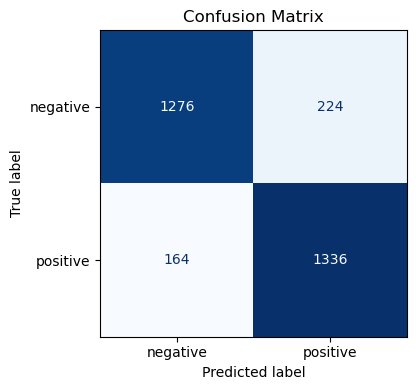

In [9]:
cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['negative', 'positive'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

## 10. Save the Deployment Artifact (sentiment_model.pkl)


In [10]:
deployment_artifact = {"vectorizer": vectorizer, "model": clf}

with open("sentiment_model.pkl", "wb") as f:
    pickle.dump(deployment_artifact, f)

print("Saved sentiment_model.pkl")

Saved sentiment_model.pkl


## 11. Sanity Check - Load the Pickle Back and Predict

In [11]:
with open("sentiment_model.pkl", "rb") as f:
    loaded_artifact = pickle.load(f)

loaded_vectorizer = loaded_artifact["vectorizer"]
loaded_model = loaded_artifact["model"]

sample_reviews = [
    "This film was absolutely brilliant, I loved every scene!",
    "What a boring and terrible waste of time.",
    "The acting was decent but the story dragged on forever.",
]

sample_clean = [clean_text(t) for t in sample_reviews]
sample_vec = loaded_vectorizer.transform(sample_clean)
sample_preds = loaded_model.predict(sample_vec)
sample_proba = loaded_model.predict_proba(sample_vec)

for text, pred, proba in zip(sample_reviews, sample_preds, sample_proba):
    label = "Positive" if pred == 1 else "Negative"
    print(f"Review: {text}\nPredicted: {label} (confidence: {max(proba)*100:.2f}%)\n")

Review: This film was absolutely brilliant, I loved every scene!
Predicted: Positive (confidence: 91.28%)

Review: What a boring and terrible waste of time.
Predicted: Negative (confidence: 99.83%)

Review: The acting was decent but the story dragged on forever.
Predicted: Negative (confidence: 63.43%)

